In [1]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib


import sys
sys.path.append('..')
import plot_settings
plot_settings.apply()

import sim_PyBaMM
importlib.reload(sim_PyBaMM);

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


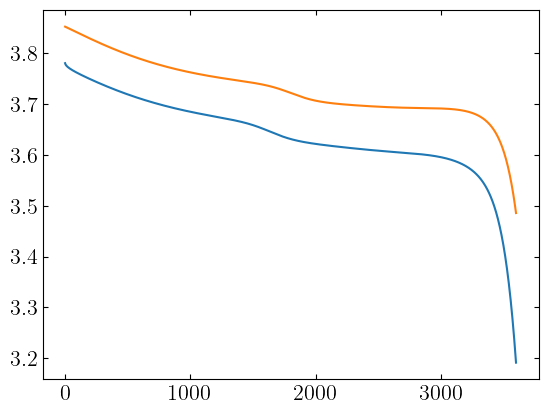

In [6]:
# -----------------------------
# 0) Load I/V data
# -----------------------------

def get_vals(T):
    '''
    Run the PyBaMM model and extract the current, voltage, and concentration
    '''
    sol, model,  param = sim_PyBaMM.simulate_DC(1.0);
    t = np.linspace(0, sol['Time [s]'].entries[-1], T)
    I = sol.observe(model.variables['Current [A]'])(t)
    V = sol.observe(model.variables['Terminal voltage [V]'])(t)
    cn = sol.observe(model.variables['X-averaged negative particle concentration [mol.m-3]'])(t)[-1, :] # Surface conc.
    cp = sol.observe(model.variables['X-averaged positive particle concentration [mol.m-3]'])(t)[-1, :] # Surface conc.
    ocv = sol.observe(model.variables['Battery open-circuit voltage [V]'])(t)
    # print(param['Nominal cell capacity [A.h]'])
    # print(t[-1])
    return t, V, I, cn, cp,ocv

def gen_data_I_c(B, T):
    '''
    B: batch size, T: time steps
    '''
    V = np.zeros((B, T, 1)) # 1 channel
    I = np.zeros((B, T, 1))
    I_dot = np.zeros((B, T, 1))
    cn = np.zeros((B, T, 1))
    cp = np.zeros((B, T, 1))
    cn_dot = np.zeros((B, T, 1))
    cp_dot = np.zeros((B, T, 1))

    for i in trange(B):
        t, V[i, :, 0], I[i, :, 0], cn[i, :, 0], cp[i, :, 0] = get_vals(T)
        
        I[i, 0, 0] = 0  # Set initial current to zero for consistency

        # dt = t[1] - t[0]  # Assuming uniform time steps
        dt = 1  # Override dt to 1 step for simplicity --> cn_dot = cn_delta
        # cn_dot[i, 0, :] = np.gradient(cn[i, 0, :], dt)

        cn_dot[:, :-1] = np.diff(cn, axis=1)
        cp_dot[:, :-1] = np.diff(cp, axis=1)
        I_dot[:, 1:] = np.diff(I, axis=1) # Backward difference, first time step is zero

        cn_dot[:, -1] = cn_dot[:, -2]  # Pad last time step with second to last value
        cp_dot[:, -1] = cp_dot[:, -2]  # Pad last time

    return I, I_dot, V, cn, cn_dot, cp, cp_dot

t, V, I, cn, cp, ocv = get_vals(1000)
plt.plot(t, V, label='Current (A)')
plt.plot(t,ocv, label='Voltage (V)')
# I, I_dot, V, cn, cn_dot, cp, cp_dot = gen_data_I_c(1, 1000)
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
# ax1.plot(I[0, :, 0], label='I')
# ax2.plot(I_dot[0, :, 0], label='I_dot')
# print(I[0, :10, 0])

In [81]:
sol, model, param = sim_PyBaMM.simulate_GRF();
cn_max = param['Maximum concentration in negative electrode [mol.m-3]']
cp_max = param['Maximum concentration in positive electrode [mol.m-3]']
print(cn_max, cp_max)

24983.2619938437 51217.9257309275


In [84]:
''' Generate data '''
B = 400
T = int(sol['Time [s]'].entries[-1]) # Use the original time steps from PyBaMM solution


B1 = 50
T1 = 1000
I, I_dot, V, cn, cn_dot, cp, cp_dot = gen_data_I_c(B1, T1)
np.savez('GRF_data_c_dot.npz', I=I, I_dot=I_dot, V=V, cn=cn, cn_dot=cn_dot, cp=cp, cp_dot=cp_dot)

100%|██████████| 50/50 [02:12<00:00,  2.65s/it]


In [87]:
#I = np.load('data_c_dot3.npz')['I']
#I_dot = np.load('data_c_dot3.npz')['I_dot']
#V = np.load('data_c_dot3.npz')['V']
#cn = np.load('data_c_dot3.npz')['cn']
#cn_dot = np.load('data_c_dot3.npz')['cn_dot']
#cp = np.load('data_c_dot3.npz')['cp']
#cp_dot = np.load('data_c_dot3.npz')['cp_dot']

In [85]:
''' Split data '''
# Split batches
test_size = 0.1
split = int(test_size * B)

def split_data(data, split):
    return data[:split], data[split:]

# Split and convert to float32 for PyTorch
I_test, I_train = split_data(I, split)
I_dot_test, I_dot_train = split_data(I_dot, split)

cn_test, cn_train = split_data(cn, split)
cn_dot_test, cn_dot_train = split_data(cn_dot, split)

cp_test, cp_train = split_data(cp, split)
cp_dot_test, cp_dot_train = split_data(cp_dot, split)

V_test, V_train = split_data(V, split)

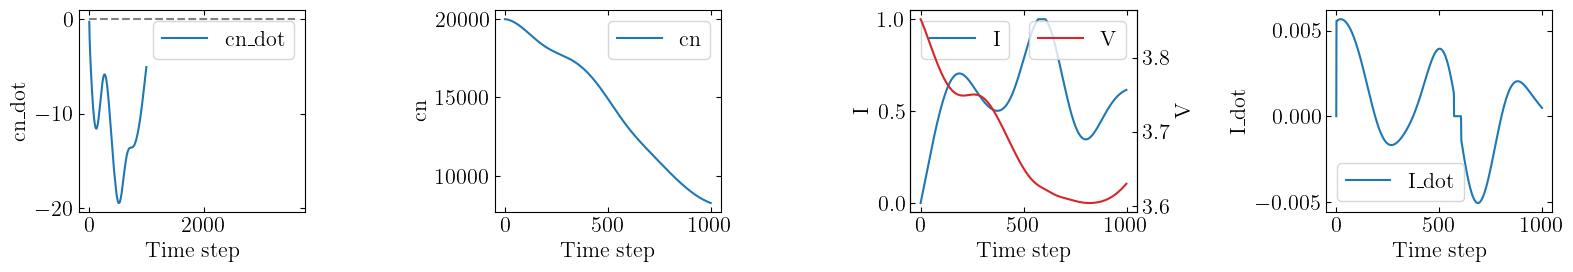

In [86]:
idb = 2

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 3))
ax1.plot(cn_dot_train[idb, :, 0], label='cn_dot')
ax1.hlines(0, 0, T, colors='gray', linestyles='dashed')
ax1.set_xlabel('Time step')
ax1.set_ylabel('cn_dot')
ax1.legend()

ax2.plot(cn_train[idb, :, 0], label='cn')
ax2.set_xlabel('Time step')
ax2.set_ylabel('cn')
ax2.legend()

ax3_ = ax3.twinx()
ax3.plot(I_train[idb, :, 0], label='I')
ax3_.plot(V_train[idb, :, 0], label='V', color='tab:red')
ax3_.set_ylabel('V')
ax3.set_xlabel('Time step')
ax3.set_ylabel('I')
ax3.legend()
ax3_.legend()

ax4.plot(I_dot_train[idb, :, 0], label='I_dot')
ax4.set_xlabel('Time step')
ax4.set_ylabel('I_dot')
ax4.legend()
plt.tight_layout()

In [ ]:
# -----------------------------
# 1) Scaling
# -----------------------------

scaler_I = StandardScaler()
scaler_I_dot = StandardScaler()
# scaler_cn = StandardScaler()
# scaler_cn_dot = StandardScaler()
scaler_cn_dot = MinMaxScaler()

def scale(data, scaler):
    B, T, C = data.shape
    data_flat = data.reshape(-1, C)  # (B*T, C)

    data_scaled_flat = scaler.fit_transform(data_flat)  # (B*T, C)
    return data_scaled_flat.reshape(B, T, C)  # (B, T, C)

''' Unused scaling for I, since it is already in a reasonable range '''
I_train_s = scale(I_train, scaler_I)
I_test_s = scale(I_test, scaler_I)

''' Scale Mark 1 '''
# # Scale cn with max 
# cn_train_s = cn_train / cn_max
# cn_test_s = cn_test / cn_max

# cn_dot_train_s = cn_dot_train / cn_max
# cn_dot_test_s = cn_dot_test / cn_max

# # cn_dot_train_s = scale(cn_dot_train, scaler_cn_dot)
# # cn_dot_test_s = scale(cn_dot_test, scaler_cn_dot)

# # cn_train_s = scale(cn_train, scaler_cn)
# # cn_test_s = scale(cn_test, scaler_cn)
# # # Scale with STD from cn
# # cn_dot_train_s = cn_dot_train / scaler_cn.scale_[0]  # Scale cn_dot by the same factor as cn
# # cn_dot_test_s = cn_dot_test / scaler_cn.scale_[0]  # Scale cn_dot by the same factor as cn

''' Scale Mark 2 '''
cn_scale = cn_max
cn_dot_scale = np.max(np.abs(cn_dot_train))

cn_train_s = cn_train / cn_scale
cn_test_s = cn_test / cn_scale
cn_dot_train_s = cn_dot_train / cn_dot_scale    # ≠ cn_dot_train_s = scale(cn_dot_train, MinMaxScaler())
cn_dot_test_s = cn_dot_test / cn_dot_scale



print(f"cn_scale: {cn_scale:.2e}, cn_dot_scale: {cn_dot_scale:.2e}")
print(f"cn_train_s range: [{cn_train_s.min():.2f}, {cn_train_s.max():.2f}]"
      f", cn_dot_train_s range: [{cn_dot_train_s.min():.2f}, {cn_dot_train_s.max():.2f}]")


train_dataset = TensorDataset(torch.tensor(I_train, dtype=torch.float32),    # Not using scaled
                              torch.from_numpy(I_dot_train).float(), 
                              torch.from_numpy(cn_train_s).float(), 
                              torch.from_numpy(cn_dot_train_s).float())


''' Scale Mark 3 '''
# cn_scale = cn_max
# cn_dot_scale = np.max(np.abs(cn_dot_train))

# cn_train_s = cn_train / cn_scale
# cn_test_s = cn_test / cn_scale
# cn_dot_train_s = cn_dot_train / cn_dot_scale    # ≠ cn_dot_train_s = scale(cn_dot_train, MinMaxScaler())
# cn_dot_test_s = cn_dot_test / cn_dot_scale

# print(f"cn_scale: {cn_scale:.2e}, cn_dot_scale: {cn_dot_scale:.2e}")
# print(f"cn_train_s range: [{cn_train_s.min():.2f}, {cn_train_s.max():.2f}]"
#       f", cn_dot_train_s range: [{cn_dot_train_s.min():.2f}, {cn_dot_train_s.max():.2f}]")


# I_dot_train_s = scale(I_dot_train, scaler_I_dot)    # Made no difference
# I_dot_test_s = scale(I_dot_test, scaler_I_dot)
# I_dot_train_s = I_dot_train / scaler_I.scale_[0]  # Scale I_dot by the same factor as I   # No difference
# I_dot_test_s = I_dot_test / scaler_I.scale_[0]  
# I_dot_scale = np.max(np.abs(I_dot_train))
# I_dot_train_s = I_dot_train / I_dot_scale  # Scale I_dot by its own max value
# I_dot_test_s = I_dot_test / I_dot_scale

# print(f"I_dot_scale: {scaler_I.scale_[0]:.2e}")
# print(f"I_dot_train_s range: [{I_dot_train_s.min():.2f}, {I_dot_train_s.max():.2f}]")

# train_dataset = TensorDataset(torch.tensor(I_train, dtype=torch.float32),    # Not using scaled
#                               torch.from_numpy(I_dot_train).float(), 
#                               torch.from_numpy(cn_train_s).float(), 
#                               torch.from_numpy(cn_dot_train_s).float())

batch_size = int(B/3)
loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)


cn_scale: 2.50e+04, cn_dot_scale: 2.30e+01
cn_train_s range: [0.17, 0.80], cn_dot_train_s range: [-1.00, -0.00]


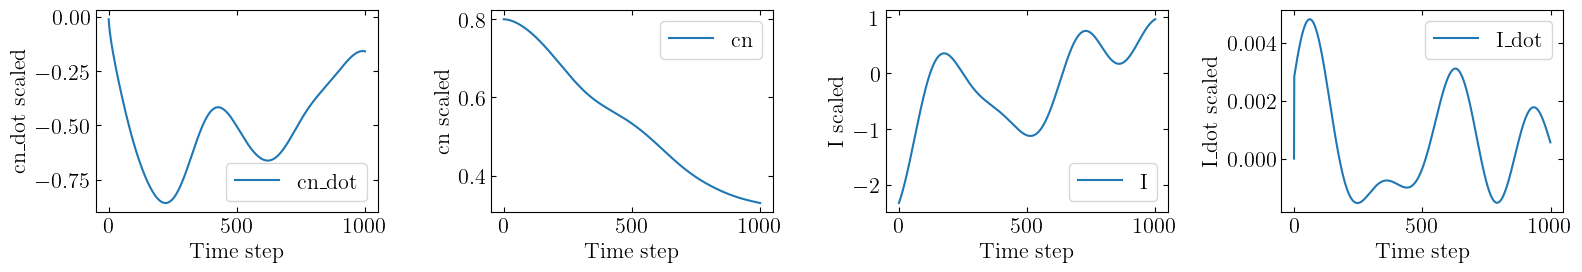

In [95]:
idb = 7

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 3))
ax1.plot(cn_dot_train_s[idb, :, 0], label='cn_dot')
ax1.set_xlabel('Time step')
ax1.set_ylabel('cn_dot scaled')
ax1.legend()
ax2.plot(cn_train_s[idb, :, 0], label='cn')
ax2.set_xlabel('Time step')
ax2.set_ylabel('cn scaled')
ax2.legend()
ax3.plot(I_train[idb, :, 0], label='I')
ax3.set_xlabel('Time step')
ax3.set_ylabel('I scaled')
ax3.legend()
ax4.plot(I_dot_train[idb, :, 0], label='I_dot')
ax4.set_xlabel('Time step')
ax4.set_ylabel('I_dot scaled')
ax4.legend()
plt.tight_layout()

In [96]:
# -----------------------------
# 2) Network
# -----------------------------

class Net(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features=3, out_features=hidden_dim), # input i_t, i_dot_t, c_t
            nn.Tanh(),
            nn.Linear(hidden_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1),  # output c_dot_k
        )

    def forward(self, I, I_dot, c):
        # x: [B*T, 1], c: [B*T, 1]
        x = torch.cat([I, I_dot, c], dim=-1)  # [B*T, 3]
        output = self.net(x)
        return output
    
    def compute_l1_loss(self, w):
      return torch.abs(w).sum()

In [98]:
# -----------------------------
# 3) Training loop
# -----------------------------

model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()

def training(epochs=50):
    history = {"loss": []}
    for ep in range(epochs):
        model.train()
        last = None

        for I_batch, I_dot_batch, cn_batch, cn_dot_batch in loader:
            # batch: (B, T, 1) -> (B*T, 1)
            I_flat = I_batch.reshape(-1, 1)
            I_dot_flat = I_dot_batch.reshape(-1, 1)
            cn_flat = cn_batch.reshape(-1, 1)
            y_flat = cn_dot_batch.reshape(-1, 1)
            
            # predict parameters
            cn_dot_hat = model(I_flat, I_dot_flat, cn_flat)

            loss = mse(cn_dot_hat, y_flat)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            last = loss.item()

        history["loss"].append(last)

        print(f'Epoch {ep+1} | loss {last} |')

    return history


  

In [101]:
history = training(epochs=10000)

Epoch 1 | loss None |
Epoch 2 | loss None |
Epoch 3 | loss None |
Epoch 4 | loss None |
Epoch 5 | loss None |
Epoch 6 | loss None |
Epoch 7 | loss None |
Epoch 8 | loss None |
Epoch 9 | loss None |
Epoch 10 | loss None |
Epoch 11 | loss None |
Epoch 12 | loss None |
Epoch 13 | loss None |
Epoch 14 | loss None |
Epoch 15 | loss None |
Epoch 16 | loss None |
Epoch 17 | loss None |
Epoch 18 | loss None |
Epoch 19 | loss None |
Epoch 20 | loss None |
Epoch 21 | loss None |
Epoch 22 | loss None |
Epoch 23 | loss None |
Epoch 24 | loss None |
Epoch 25 | loss None |
Epoch 26 | loss None |
Epoch 27 | loss None |
Epoch 28 | loss None |
Epoch 29 | loss None |
Epoch 30 | loss None |
Epoch 31 | loss None |
Epoch 32 | loss None |
Epoch 33 | loss None |
Epoch 34 | loss None |
Epoch 35 | loss None |
Epoch 36 | loss None |
Epoch 37 | loss None |
Epoch 38 | loss None |
Epoch 39 | loss None |
Epoch 40 | loss None |
Epoch 41 | loss None |
Epoch 42 | loss None |
Epoch 43 | loss None |
Epoch 44 | loss None

In [92]:
# -----------------------------
# 4) Test + plot
# -----------------------------
''' Predicted on known cn, not using Euler to step forward '''
model.eval()
idx = 1

cn_dot_hat_list = []
cn_euler = np.zeros_like(cn_test_s)  # (B, T, 1)
cn_t = torch.tensor([[cn_test_s[idx, 0, 0]]], dtype=torch.float32).item()
cn_euler[idx, 0, 0] = cn_t

dt = 1 

def step(idx, t, cn_dot_hat, dt=dt):
    # Euler step: c_{k+1} = c_k + c_dot_k * dt
    cn_euler[idx, t+1, 0] = cn_euler[idx, t, 0] + cn_dot_hat * dt
    # cn_euler[idx, t+1, 0] = torch.clamp(torch.tensor(cn_euler[idx, t+1, 0]), min=0.3, max=1.5)

for t in range(T):
    I_t  = torch.tensor([[I_test[idx, t, 0]]], dtype=torch.float32)   # (1,1)
    I_dot_t = torch.tensor([[I_dot_test[idx, t, 0]]], dtype=torch.float32)   # (1,1)
    cn_t = torch.tensor([[cn_test_s[idx, t, 0]]], dtype=torch.float32)  # (1,1)

    with torch.no_grad():
        cn_dot_hat = model(I_t, I_dot_t, cn_t).item()   # pick item from output tensor

    cn_dot_hat_list.append(cn_dot_hat)
    
    if t < T-1:  # Avoid stepping beyond the last time step
        step(idx, t, cn_dot_hat)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

ax1_ = ax1.twinx()

ax1.plot(cn_dot_test_s[idx, :, 0], color="tab:red", linestyle="dashed", label="True $\\dot{c}_n(t)$")
ax1.plot(cn_dot_hat_list, color="tab:blue", label="Predicted $\\dot{c}_n(t)$")
ax1_.plot(I_test[idx, :, 0], label='I', color='black', linestyle='dotted')
ax1.set_xlabel("Time step")
ax1.set_ylabel("Concentration rate (scaled)")
ax1.legend()

ax2.plot(cn_test_s[idx, :, 0], color="tab:red", linestyle="dashed", label="True $c_n(t)$")
ax2.plot(cn_euler[idx, :, 0], color="tab:blue", label="Predicted $c_n(t)$")
ax2.set_xlabel("Time step")
ax2.set_ylabel("Concentration (scaled)")
ax2.legend()

ax3.plot(history["loss"], label="Train loss")
ax3.set_xlabel("epoch")
ax3.set_ylabel("MSE (scaled)")
ax3.legend()

plt.tight_layout()

IndexError: index 1000 is out of bounds for axis 1 with size 1000

Initial cn: 0.8000
-52.25062654539943 0.4376759162866018


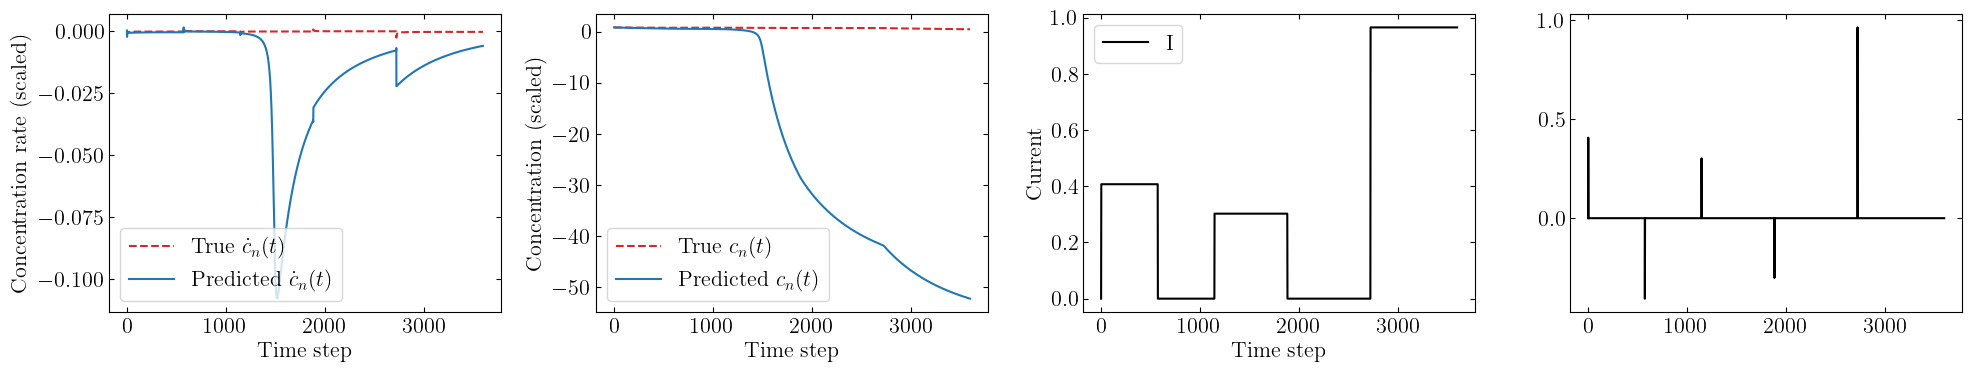

In [ ]:
# -----------------------------
# 5) Predict from euler forward 
# -----------------------------
model.eval()
idx = 0

cn_euler = np.zeros_like(cn_test_s)  # (B, T, 1)

''' Using true initial cn, then forward Euler '''
cn_0 = torch.tensor([[cn_test_s[idx, 0, 0]]], dtype=torch.float32).item()
cn_euler[idx, 0, 0] = cn_0
print(f"Initial cn: {cn_0:.4f}")

cn_dot_hat_list = []
# dt = t_tot / T  # Total time divided by number of steps, assuming uniform spacing
dt = 1


def step(idx, t, I_t, I_dot, cn_t):
    # Predict cn_dot from current I_t and concentration cn_t
    with torch.no_grad():
            cn_dot_hat_s = model(I_t, I_dot, cn_t).item()    # pick item from output tensor

    cn_euler[idx, t+1, 0] = cn_euler[idx, t, 0] + cn_dot_hat_s * dt   # Euler step: c_{k+1} = c_k + c_dot_k * dt
    return cn_dot_hat_s


for t in range(T):
    I_t  = torch.tensor([[I_test[idx, t, 0]]], dtype=torch.float32)   # (1,1)
    I_dot_t = torch.tensor([[I_dot_test[idx, t, 0]]], dtype=torch.float32)   # (1,1)

    if t == 0:
        # Predict on initial concentration, then use Euler to step forward
        cn_t = torch.tensor([[cn_test_s[idx, t, 0]]], dtype=torch.float32)  # (1,1)
        cn_dot_hat = step(idx, t, I_t, I_dot_t, cn_t)
    elif t < T-1:
        cn_t = torch.tensor([[cn_euler[idx, t, 0]]], dtype=torch.float32)  # (1,1)
        cn_dot_hat = step(idx, t, I_t, I_dot_t, cn_t)

    cn_dot_hat_list.append(cn_dot_hat)
    # print(f"True cn_dot: {cn_dot_test_s[idx, t, 0]:.4f} | Predicted cn_dot: {cn_dot_hat:.4f}")

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 4))

ax1.plot(cn_dot_test_s[idx, :, 0],  color="tab:red", linestyle="dashed", label="True $\\dot{c}_n(t)$")
ax1.plot(cn_dot_hat_list, color="tab:blue", label="Predicted $\\dot{c}_n(t)$")
ax1.set_xlabel("Time step")
ax1.set_ylabel("Concentration rate (scaled)")
ax1.legend()

ax2.plot(cn_test_s[idx, :, 0], color="tab:red", linestyle="dashed", label="True $c_n(t)$")
ax2.plot(cn_euler[idx, :, 0], color="tab:blue", label="Predicted $c_n(t)$")
ax2.set_xlabel("Time step")
ax2.set_ylabel("Concentration (scaled)")
ax2.legend()

ax3.plot(I_test[idx, :, 0], label='I', color='black')
ax3.set_xlabel("Time step")
ax3.set_ylabel("Current")
ax3.legend()

ax4.plot(I_dot_test[idx, :, 0], label='I_dot', color='black')
plt.tight_layout()

# plt.savefig('figs/2_JN_PENN_ECM.pdf')

print(cn_euler[idx, -1, 0], cn_test_s[idx, -1, 0])